# Backtest 005f — TTM Breakout + GKYZ Entry Filter

Fork of **backtest_005e** that changes GKYZ from a **position-sizing** mechanism
to a hard **entry gate**.

## Regime logic

| Condition | State |
|-----------|-------|
| GKYZ (normalised) crosses **above upper** | **risk-on** |
| GKYZ stays in `[lower, upper]` | hold previous state |
| GKYZ crosses **below lower** | **risk-off** |

**Entry filter (applied to both VNINDEX and the individual symbol)**

| Entry version | Regime required to open a trade |
|---------------|---------------------------------|
| **v3** (mean-reversion) | VNINDEX **risk-on = True** AND symbol **risk-on = True** |
| **v1 / v2** (trend-following) | VNINDEX **risk-on = False** AND symbol **risk-on = False** |

No position-sizing adjustment — trades either happen at normal size or are blocked entirely.

In [104]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numba as nb
import vectorbt as vbt
import optuna
import talib
optuna.logging.set_verbosity(optuna.logging.WARNING)

sys.path.insert(0, str(pathlib.Path('..').resolve()))
from backend.app.services.indicators.trailing_sl import atr_trailing_nb
from backend.app.services.indicators.wiliams_vix_fix import williams_vix_fix_indicator
from backend.app.services.indicators.gkyz_volatility import calculate_gkyz_volatility
from backend.app.services.indicators.yang_zhang_volatility import calculate_yz_volatility
from backend.app.services.indicators.vwap import avwap_func_nb

plt.style.use('dark_background')
print('imports ok')

imports ok


## 1. Load Data

In [105]:
REMOTE_HOST = 'http://192.168.1.30:9000'

def load_stock_data() -> pd.DataFrame:
    from deltalake import DeltaTable
    storage_options = {
        'AWS_ACCESS_KEY_ID':          'CzOwnLkEDXQy951AOqes',
        'AWS_SECRET_ACCESS_KEY':      'fdRe91TOtqTl0icUkZLsUnWvZa90aZ5qG5rVEf7S',
        'AWS_ENDPOINT_URL':           REMOTE_HOST,
        'AWS_ALLOW_HTTP':             'true',
        'AWS_EC2_METADATA_DISABLED':  'true',
        'AWS_REGION':                 'us-east-1',
        'aws_conditional_put':        'etag',
    }
    watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
    watchlist_symbols = watchlist_df.iloc[:, 0].values
    start_date        = pd.Timestamp.now() - pd.DateOffset(years=10)

    dt = DeltaTable('s3://delta-table-storage/stocks', storage_options=storage_options)
    raw = dt.to_pandas(
        filters=[('date', '>=', start_date), ('symbol', 'in', watchlist_symbols)],
        columns=['symbol', 'date', 'close', 'open', 'high', 'low', 'volume'],
    )
    raw = raw.drop_duplicates(subset=['date', 'symbol'], keep='last')
    raw = raw.set_index(['date', 'symbol'])
    stocks = raw.unstack(level=1).bfill().ffill()
    print('Loaded from DeltaLake')
    return stocks


local_file = 'stocks_data_latest.h5'
store_key  = 'stocks'

if os.path.exists(local_file):
    print(f'Loading from local HDF5: {local_file}')
    with pd.HDFStore(local_file, mode='r') as store:
        df_raw = store[store_key]
else:
    print('HDF5 not found — loading from DeltaLake ...')
    df_raw = load_stock_data()
    with pd.HDFStore(local_file, mode='w') as store:
        store.put(store_key, df_raw)

watchlist_df      = pd.read_csv('../backend/models/watchlist.csv')
watchlist_symbols = watchlist_df.iloc[:, 0].values
df_raw = df_raw.loc[:, df_raw.columns.get_level_values('symbol').isin(watchlist_symbols)]

open_   = df_raw['open']
high    = df_raw['high']
low     = df_raw['low']
close   = df_raw['close']
volume  = df_raw['volume']

print(f'Shape: {close.shape}  |  {close.index[0]} -> {close.index[-1]}')
close.tail(3)

Loading from local HDF5: stocks_data_latest.h5
Shape: (2499, 195)  |  2016-05-06 00:00:00 -> 2026-05-05 00:00:00


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-04-29,7.31,14.9,23.5,44.0,9.09,12.60,14.50,23.90,5.83,5.63,...,1854.70,60.9,12.60,26.50,3.49,61.4,32.3,21.35,68.0,10.00
2026-05-04,7.48,15.0,23.1,44.0,9.02,12.50,14.55,23.95,5.95,6.02,...,1853.19,60.9,12.55,26.95,3.48,61.3,33.7,21.60,68.0,10.00
2026-05-05,7.37,14.9,22.6,44.8,9.02,12.35,14.40,23.45,5.84,6.27,...,1873.31,61.1,12.45,28.00,3.50,62.5,35.2,21.45,65.9,9.96


## 2. TTM Breakout Helpers

In [106]:
@nb.njit
def shift_2d(arr, num, fill_value=np.nan):
    result = np.empty_like(arr)
    n = arr.shape[0]
    if num > 0:
        result[:num, :] = fill_value
        result[num:, :] = arr[:n - num, :]
    elif num < 0:
        result[n + num:, :] = fill_value
        result[:n + num, :] = arr[-num:, :]
    else:
        result[:, :] = arr
    return result


@nb.njit
def count_consecutive_neg_2d(arr):
    n, m  = arr.shape
    out   = np.zeros((n, m), dtype=np.int64)
    for j in range(m):
        count = 0
        for i in range(n):
            if arr[i, j] < 0:
                count += 1
                out[i, j] = count
            else:
                count = 0
    return out


@nb.njit(cache=True)
def kama_2d(prices_np, period=10, fast=2, slow=30):
    n, m    = prices_np.shape
    out     = np.full((n, m), np.nan)
    fast_sc = 2.0 / (fast + 1)
    slow_sc = 2.0 / (slow + 1)
    for j in range(m):
        kama = prices_np[period - 1, j]
        out[period - 1, j] = kama
        for i in range(period, n):
            direction  = abs(prices_np[i, j] - prices_np[i - period, j])
            volatility = 0.0
            for k in range(1, period + 1):
                volatility += abs(prices_np[i - k + 1, j] - prices_np[i - k, j])
            er = direction / volatility if volatility != 0.0 else 0.0
            sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2
            kama = kama + sc * (prices_np[i, j] - kama)
            out[i, j] = kama
    return out


@nb.njit(cache=True)
def slope_flat_2d(kama_np, slope_window, flat_threshold_pct):
    n, m = kama_np.shape
    out  = np.zeros((n, m), dtype=nb.boolean)
    for j in range(m):
        for i in range(slope_window, n):
            prev = kama_np[i - slope_window, j]
            if prev != 0.0 and not np.isnan(prev) and not np.isnan(kama_np[i, j]):
                slope_pct = abs((kama_np[i, j] - prev) / prev * 100.0)
                out[i, j] = slope_pct < flat_threshold_pct
    return out


print('Numba helpers compiled')

Numba helpers compiled


In [107]:
AVWAP = vbt.IndicatorFactory(
    class_name='AVWAP', short_name='avwap',
    input_names=['close', 'high', 'low', 'volume'],
    param_names=['is_highest', 'window'],
    output_names=['avwap'],
).from_apply_func(avwap_func_nb)
_avwap_lowest_cache = {}


def get_avwap_lowest(close, high, low, volume, window: int = 200):
    key = (id(close), id(high), id(low), id(volume), int(window))
    if key not in _avwap_lowest_cache:
        avwap = AVWAP.run(close, high, low, volume, is_highest=[False], window=int(window)).avwap
        avwap_lowest = avwap.xs(False, level='avwap_is_highest', axis=1)
        avwap_lowest.columns = avwap_lowest.columns.get_level_values(-1)
        _avwap_lowest_cache[key] = avwap_lowest.reindex(columns=close.columns)
    return _avwap_lowest_cache[key]


def compute_signals(
    close, high, low, volume=None,
    bb_window=16, bb_multiplier=1.0, bb_matype=0,
    kc_window=40, kc_multiplier=1.2, kc_atr_period=10,
    donichan_window=12, osc_smoothing_period=10,
    entry_version='v3', consecutive_neg_threshold=7,
    william_vix_period=20,
    use_avwap_filter=False, avwap_window=200,
    use_kama_slope=True, kama_period=10, kama_fast=2, kama_slow=30,
    kama_slope_win=5, flat_threshold_pct=1.0,
    mrs_window=21,
):
    BB   = vbt.IndicatorFactory.from_talib('BBANDS')
    ATR  = vbt.IndicatorFactory.from_talib('ATR')
    EMA  = vbt.IndicatorFactory.from_talib('EMA')
    SMA  = vbt.IndicatorFactory.from_talib('SMA')
    MAX  = vbt.IndicatorFactory.from_talib('MAX')
    LREG = vbt.IndicatorFactory.from_talib('LINEARREG')

    bb  = BB.run(close, timeperiod=bb_window,
                 nbdevup=bb_multiplier, nbdevdn=bb_multiplier, matype=bb_matype)
    atr = ATR.run(high, low, close, timeperiod=kc_atr_period)
    ema = EMA.run(close, timeperiod=kc_window)

    bb_upper_np  = bb.upperband.to_numpy()
    bb_lower_np  = bb.lowerband.to_numpy()
    ema_np       = ema.real.to_numpy()
    atr_np       = atr.real.to_numpy()
    kc_upper_np  = ema_np + kc_multiplier * atr_np
    kc_lower_np  = ema_np - kc_multiplier * atr_np

    hh  = MAX.run(high, timeperiod=donichan_window).real.to_numpy()
    ll  = MAX.run(low,  timeperiod=donichan_window).real.to_numpy()
    sma = SMA.run(close, timeperiod=donichan_window).real.to_numpy()
    close_np  = close.to_numpy()
    histogram = close_np - ((hh + ll) / 2 + sma) / 2
    ttms_np   = LREG.run(
        pd.DataFrame(histogram, index=close.index, columns=close.columns),
        timeperiod=osc_smoothing_period,
    ).real.to_numpy()

    _, _, _, wvf_signal = williams_vix_fix_indicator(
        close, high, low,
        period=william_vix_period, mult=bb_multiplier,
        bbl=bb_window, lb=20, ph=0.85, ltLB=33, mtLB=10, strength_str=1,
    )
    wvf_np = wvf_signal if isinstance(wvf_signal, np.ndarray) else wvf_signal.to_numpy()

    if use_avwap_filter and volume is not None:
        avwap_lowest = get_avwap_lowest(close, high, low, volume, avwap_window)
        avwap_prev_np = shift_2d(avwap_lowest.to_numpy(dtype=np.float64), 1)
        avwap_filter_np = (close_np > avwap_prev_np) & (~np.isnan(avwap_prev_np))
    else:
        avwap_filter_np = np.ones_like(close_np, dtype=np.bool_)

    if use_kama_slope:
        kama_np = kama_2d(close_np.astype(np.float64), kama_period, kama_fast, kama_slow)
        flat_np = slope_flat_2d(kama_np, kama_slope_win, flat_threshold_pct)
    else:
        flat_np = np.ones_like(close_np, dtype=np.bool_)

    if entry_version == 'v1':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        entries_np = no_sqz_np & (ttms_np > 0) & flat_np
    elif entry_version == 'v2':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        ttms_1 = shift_2d(ttms_np, 1); ttms_2 = shift_2d(ttms_np, 2); ttms_3 = shift_2d(ttms_np, 3)
        crossed_now  = (ttms_1 < 0) & (ttms_np > 0)
        crossed_1ago = (ttms_2 < 0) & (ttms_1  > 0)
        crossed_2ago = (ttms_3 < 0) & (ttms_2  > 0)
        cond_2  = (ttms_np > ttms_1) & crossed_1ago
        cond_3  = (ttms_np > ttms_2) & crossed_2ago
        entries_np = no_sqz_np & (crossed_now | cond_2 | cond_3) & flat_np
    else:  # v3
        entries_np = wvf_np

    # ── Mansfield Relative Strength (MRS) filter — v1 / v2 only ──────────────
    # if entry_version in ('v1', 'v2') and 'VNINDEX' in close.columns:
    #     vnidx_close = close['VNINDEX'].values[:, np.newaxis]
    #     rsd_np      = close.values / vnidx_close * 100
    #     rsd_df      = pd.DataFrame(rsd_np, index=close.index, columns=close.columns)
    #     ma_rsd_np   = rsd_df.rolling(mrs_window).mean().values
    #     with np.errstate(divide='ignore', invalid='ignore'):
    #         mrs_np  = np.where(ma_rsd_np != 0, (rsd_np / ma_rsd_np - 1) * 100, np.nan)
    #     entries_np  = entries_np & (mrs_np > 0)

    entries_np = entries_np & avwap_filter_np
    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(close, high, low, atr_multiplier=1.9, atr_period=10, lookback=5):
    """
    Returns (atr_exit, sl_stop_df).
    - atr_exit   : ATR trailing stop crossover signal (dynamic).
    - sl_stop_df : lowest_low(lookback) as a % below close — vectorbt samples this
                   ONCE at the entry bar, so the stop is fixed for the trade's life.
    """
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=atr_period
    )
    ATRTrailing = vbt.IndicatorFactory(
        input_names=['close', 'atr'], param_names=['atr_multiplier'],
        output_names=['atr_trailing'],
    ).from_apply_func(atr_trailing_nb)
    atr_sl   = ATRTrailing.run(close, atr_raw.real, atr_multiplier=atr_multiplier)
    atr_exit = close.vbt.crossed_below(atr_sl.atr_trailing)

    MIN        = vbt.IndicatorFactory.from_talib('MIN')
    lowest_low = MIN.run(low, timeperiod=lookback).real * 0.99  # 1% buffer below lowest low
    sl_stop_df = ((close - lowest_low) / close).clip(lower=0)

    return atr_exit, sl_stop_df


print('Signal functions defined')

Signal functions defined


## 3. GKYZ Volatility Risk Regime

Compute normalised GKYZ volatility for **VNINDEX** and each **symbol**,
then derive a hysteresis-based binary risk-on / risk-off state.

```
GKYZ > upper  ──►  risk_on = True
GKYZ < lower  ──►  risk_on = False
otherwise     ──►  hold previous state
```
**Entry gate:** v3 entries require both VNINDEX and symbol to be risk-on;
v1/v2 entries require both to be risk-off.

In [108]:
# ── GKYZ defaults ─────────────────────────────────────────────────────────────
GKYZ_WINDOW = 21
GKYZ_UPPER  = 0.8
GKYZ_LOWER  = 0.2

# ── YZ vol-ratio defaults ────────────────────────────────────────────────────
YZ_SHORT_WINDOW    = 20
YZ_LONG_WINDOW     = 120
YZ_RISK_OFF_THRESH = 1.0   # vol_ratio below this → risk_off (sticky)
YZ_RISK_ON_THRESH  = 1.0   # vol_ratio above this → risk_on  (sticky, elevated)


def compute_gkyz_regime(
    open_s, high_s, low_s, close_s,
    window=GKYZ_WINDOW, upper=GKYZ_UPPER, lower=GKYZ_LOWER,
) -> tuple:
    """Hysteresis regime: risk_on=True when GKYZ crosses above upper; False below lower."""
    gkyz_arr = calculate_gkyz_volatility(
        open_s.values.astype(np.float64), high_s.values.astype(np.float64),
        low_s.values.astype(np.float64),  close_s.values.astype(np.float64),
        window=window, normalize=True,
    )
    n = len(gkyz_arr)
    risk_on = np.zeros(n, dtype=bool)
    state   = False
    for i in range(n):
        v = gkyz_arr[i]
        if np.isnan(v):
            risk_on[i] = state; continue
        if not state and v > upper: state = True
        elif state and v < lower:  state = False
        risk_on[i] = state
    idx = close_s.index
    return pd.Series(gkyz_arr, index=idx, name='gkyz'),            pd.Series(risk_on,  index=idx, name='risk_on')


def compute_yz_regime(
    open_s, high_s, low_s, close_s,
    short_window=YZ_SHORT_WINDOW, long_window=YZ_LONG_WINDOW,
    risk_off_threshold=YZ_RISK_OFF_THRESH, risk_on_threshold=YZ_RISK_ON_THRESH,
) -> tuple:
    """
    Vol-ratio regime: YZ(short) / YZ(long).
    Zones: <0.75 risk_on (calm) | 0.75-1.0 neutral | >1.0 risk_off (elevated)
    Hysteresis:
      ratio > risk_on_threshold  → risk_on  = True  (sticky)
      ratio < risk_off_threshold → risk_on  = False (sticky)
    Returns (vol_ratio series, risk_on bool series).
    """
    def _yz(window):
        lst = calculate_yz_volatility(
            open_s.values.astype(np.float64), high_s.values.astype(np.float64),
            low_s.values.astype(np.float64),  close_s.values.astype(np.float64),
            window=window,
        )
        s = pd.Series(np.array(lst, dtype=np.float64), index=close_s.index)
        return s.replace(0, np.nan)

    yz_s      = _yz(short_window)
    yz_l      = _yz(long_window)
    vol_ratio = (yz_s / yz_l).replace([np.inf, -np.inf], np.nan)

    ratio_arr = vol_ratio.values
    n         = len(ratio_arr)
    risk_on   = np.zeros(n, dtype=bool)
    state     = False
    for i in range(n):
        v = ratio_arr[i]
        if np.isnan(v):
            risk_on[i] = state
            continue
        if state and v < risk_off_threshold:
            state = False
        elif not state and v > risk_on_threshold:
            state = True
        risk_on[i] = state

    return vol_ratio, pd.Series(risk_on, index=close_s.index, name='risk_on')


def compute_gkyz_regime_all(open_df, high_df, low_df, close_df,
                             window=GKYZ_WINDOW, upper=GKYZ_UPPER, lower=GKYZ_LOWER):
    """GKYZ risk-on boolean for every symbol. Returns (T, N) bool DataFrame."""
    result = pd.DataFrame(False, index=close_df.index, columns=close_df.columns)
    for sym in close_df.columns:
        _, ron = compute_gkyz_regime(open_df[sym], high_df[sym], low_df[sym], close_df[sym],
                                     window=window, upper=upper, lower=lower)
        result[sym] = ron.values
    return result


def compute_yz_regime_all(open_df, high_df, low_df, close_df,
                           short_window=YZ_SHORT_WINDOW, long_window=YZ_LONG_WINDOW,
                           risk_off_threshold=YZ_RISK_OFF_THRESH,
                           risk_on_threshold=YZ_RISK_ON_THRESH):
    """Vol-ratio YZ risk-on boolean for every symbol. Returns (T, N) bool DataFrame."""
    result = pd.DataFrame(False, index=close_df.index, columns=close_df.columns)
    for sym in close_df.columns:
        _, ron = compute_yz_regime(open_df[sym], high_df[sym], low_df[sym], close_df[sym],
                                   short_window=short_window, long_window=long_window,
                                   risk_off_threshold=risk_off_threshold,
                                   risk_on_threshold=risk_on_threshold)
        result[sym] = ron.values
    return result


def compute_regime(open_s, high_s, low_s, close_s, regime_version='v1', **kwargs):
    """Dispatch to GKYZ (v1) or YZ midline (v2) regime for a single series."""
    if regime_version == 'v1':
        return compute_gkyz_regime(open_s, high_s, low_s, close_s, **kwargs)
    return compute_yz_regime(open_s, high_s, low_s, close_s, **kwargs)


def compute_regime_all(open_df, high_df, low_df, close_df, regime_version='v1', **kwargs):
    """Dispatch to GKYZ (v1) or YZ midline (v2) regime for all symbols."""
    if regime_version == 'v1':
        return compute_gkyz_regime_all(open_df, high_df, low_df, close_df, **kwargs)
    return compute_yz_regime_all(open_df, high_df, low_df, close_df, **kwargs)


def apply_gkyz_entry_filter(entries, risk_on_vnindex, risk_on_symbols, entry_version):
    """
    Gate entries by regime state.
    v3    : enter only when VNINDEX AND symbol are both risk-on  (True)
    v1/v2 : enter only when VNINDEX AND symbol are both risk-off (False)
    """
    vn_mat = pd.DataFrame(
        np.tile(risk_on_vnindex.values[:, None], (1, len(entries.columns))),
        index=entries.index, columns=entries.columns,
    )
    gate = (vn_mat & risk_on_symbols) if entry_version == 'v3' else (~vn_mat & ~risk_on_symbols)
    return entries & gate


# Compute VNINDEX baseline regime (v1 / GKYZ)
gkyz_vnindex, risk_on_vnindex = compute_gkyz_regime(
    open_['VNINDEX'], high['VNINDEX'], low['VNINDEX'], close['VNINDEX'],
)
n_risk_on  = risk_on_vnindex.sum()
n_risk_off = (~risk_on_vnindex).sum()
print(f'VNINDEX  risk-on  bars: {n_risk_on}  ({n_risk_on / len(risk_on_vnindex) * 100:.1f}%)')
print(f'VNINDEX  risk-off bars: {n_risk_off} ({n_risk_off / len(risk_on_vnindex) * 100:.1f}%)')


VNINDEX  risk-on  bars: 1148  (45.9%)
VNINDEX  risk-off bars: 1351 (54.1%)


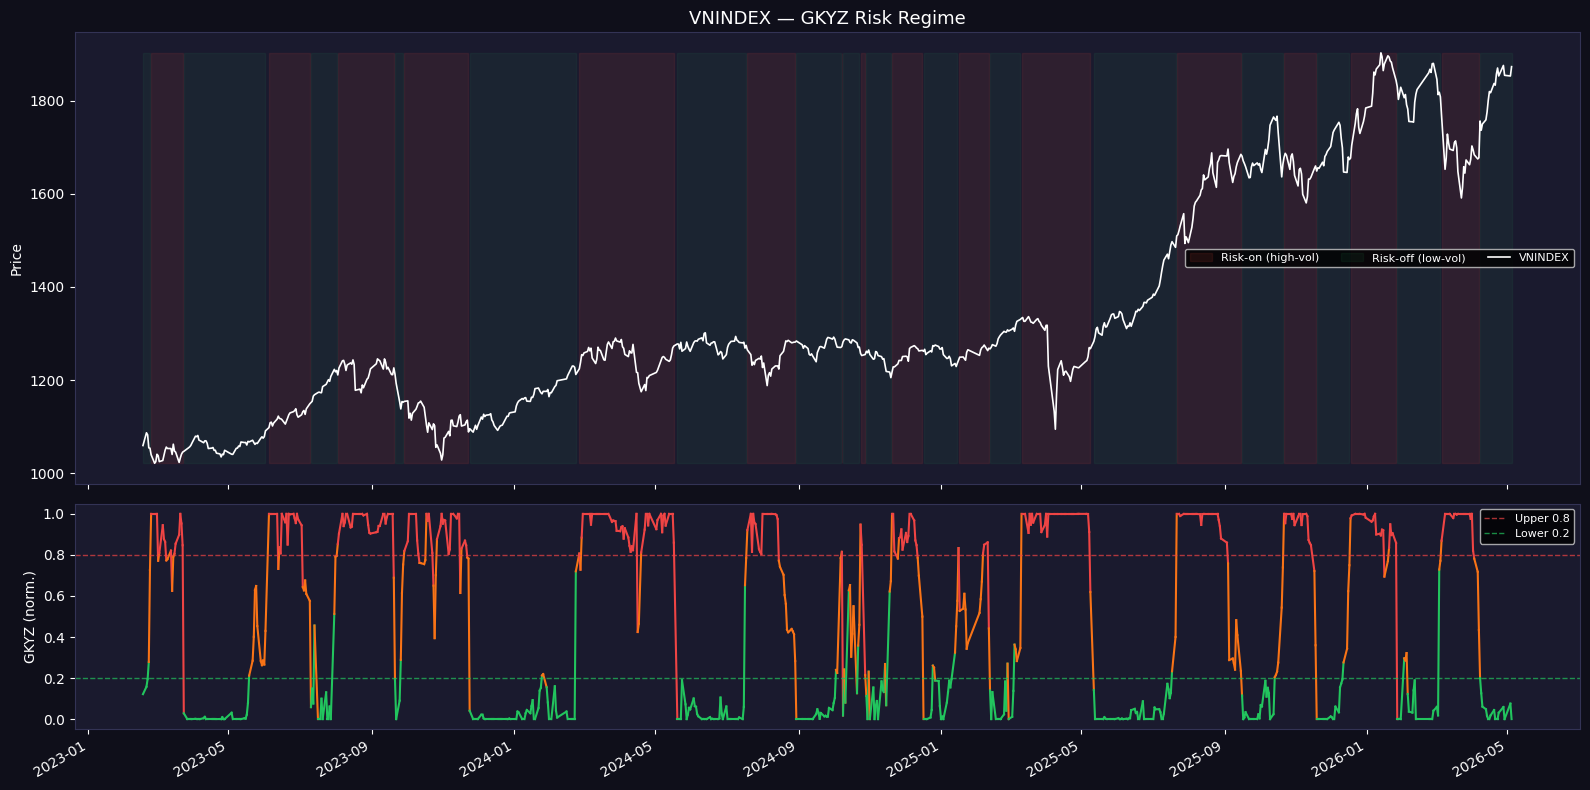

In [109]:
# ── Visualise GKYZ + regime on VNINDEX ───────────────────────────────────────
LOOKBACK = 800
sl_ = slice(-LOOKBACK, None)

dates_v  = close.index[sl_]
c_vn     = close['VNINDEX'].values[sl_]
gkyz_v   = gkyz_vnindex.values[sl_]
ron_v    = risk_on_vnindex.values[sl_]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1]})
fig.patch.set_facecolor('#0f0f1a')

ax = axes[0]
ax.set_facecolor('#1a1a2e')
ax.fill_between(dates_v, c_vn.min(), c_vn.max(),
                where=ron_v,  color='#e74c3c', alpha=0.10, label='Risk-on (high-vol)')
ax.fill_between(dates_v, c_vn.min(), c_vn.max(),
                where=~ron_v, color='#2ecc71', alpha=0.06, label='Risk-off (low-vol)')
ax.plot(dates_v, c_vn, color='white', lw=1.2, label='VNINDEX')
ax.set_title('VNINDEX — GKYZ Risk Regime', color='white', fontsize=13)
ax.set_ylabel('Price', color='white')
ax.legend(fontsize=8, ncol=3)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#333355')

ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
colors_g = np.where(gkyz_v > GKYZ_UPPER, '#ef4444',
           np.where(gkyz_v < GKYZ_LOWER, '#22c55e', '#f97316'))
for i in range(len(dates_v) - 1):
    ax2.plot(dates_v[i:i+2], gkyz_v[i:i+2], color=colors_g[i], lw=1.5)
ax2.axhline(GKYZ_UPPER, color='rgba(239,68,68,0.7)'  if False else '#ef4444',
            lw=1.0, ls='--', alpha=0.7, label=f'Upper {GKYZ_UPPER}')
ax2.axhline(GKYZ_LOWER, color='#22c55e', lw=1.0, ls='--', alpha=0.7,
            label=f'Lower {GKYZ_LOWER}')
ax2.set_ylim(-0.05, 1.05)
ax2.set_ylabel('GKYZ (norm.)', color='white')
ax2.legend(fontsize=8)
ax2.tick_params(colors='white')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=30)
for sp in ax2.spines.values(): sp.set_edgecolor('#333355')

plt.tight_layout()
plt.show()

In [115]:
# Optuna best params (005d search space — 17 tunable keys + GKYZ regime)
FIXED_TTM_PARAMS = {
    'v1': {
        'bb_window': 19, 'bb_multiplier': 1.3, 'bb_matype': 3,
        'kc_window': 55, 'kc_multiplier': 1.2, 'kc_atr_period': 6,
        'donichan_window': 10, 'osc_smoothing_period': 5,
        'low_stop_lookback': 5,
        'avwap_window': 160,
        'kama_period': 10, 'kama_fast': 5, 'kama_slow': 25,
        'kama_slope_win': 5, 'flat_threshold_pct': 3.0,
        'gkyz_window': 21, 'gkyz_upper': 0.8, 'gkyz_lower': 0.2,
        'yz_short_window': 20, 'yz_long_window': 120, 'yz_risk_off': 1.0, 'yz_risk_on': 1.0,
    },
    'v2': {
        'bb_window': 12, 'bb_multiplier': 1.4, 'bb_matype': 3,
        'kc_window': 47, 'kc_multiplier': 1.3, 'kc_atr_period': 6,
        'donichan_window': 10, 'osc_smoothing_period': 5,
        'low_stop_lookback': 5,
        'avwap_window': 20,
        'kama_period': 14, 'kama_fast': 3, 'kama_slow': 25,
        'kama_slope_win': 3, 'flat_threshold_pct': 3.0,
        'gkyz_window': 21, 'gkyz_upper': 0.8, 'gkyz_lower': 0.2,
        'yz_short_window': 20, 'yz_long_window': 120, 'yz_risk_off': 1.0, 'yz_risk_on': 1.0,
    },
    'v3': {
        'bb_window': 10, 'bb_multiplier': 1.7, 'bb_matype': 3,
        'kc_window': 27, 'kc_multiplier': 1.4, 'kc_atr_period': 5,
        'low_stop_lookback': 5,
        'consecutive_neg_threshold': 5, 'william_vix_period': 18,
        'avwap_window': 100,
        'kama_period': 6, 'kama_fast': 3, 'kama_slow': 34,
        'kama_slope_win': 18, 'flat_threshold_pct': 1.3,
        'gkyz_window': 21, 'gkyz_upper': 0.8, 'gkyz_lower': 0.2,
        'yz_short_window': 20, 'yz_long_window': 120, 'yz_risk_off': 1.0, 'yz_risk_on': 1.0,
    },
}


## 6. Final Backtest — v1 / v2 / v3 + GKYZ Entry Filter & Comparison — Stats Table

In [117]:
portfolios_gkyz = {}
portfolios_ttm  = {}

DEFAULT_YZ_LONG_WINDOW  = 60
DEFAULT_YZ_SHORT_WINDOW = 20

for ver in ['v1', 'v2', 'v3']:
    p  = FIXED_TTM_PARAMS[ver]
    rv = p.get('regime_version', 'v1')

    entries = compute_signals(
        close, high, low, volume,
        bb_window=p['bb_window'], bb_multiplier=p['bb_multiplier'],
        bb_matype=p.get('bb_matype', 0),
        kc_window=p['kc_window'], kc_multiplier=p['kc_multiplier'],
        kc_atr_period=p['kc_atr_period'],
        donichan_window=p.get('donichan_window', 10),
        osc_smoothing_period=p.get('osc_smoothing_period', 5),
        entry_version=ver,
        consecutive_neg_threshold=p.get('consecutive_neg_threshold', 7),
        william_vix_period=p.get('william_vix_period', 20),
        use_avwap_filter=True,
        avwap_window=p.get('avwap_window', 200),
        use_kama_slope=True,
        kama_period=p.get('kama_period', 10),
        kama_fast=p.get('kama_fast', 2),
        kama_slow=p.get('kama_slow', 30),
        kama_slope_win=p.get('kama_slope_win', 5),
        flat_threshold_pct=p.get('flat_threshold_pct', 1.0),
    )
    exits, sl_stop_df = compute_exits(
        close, high, low,
        atr_multiplier=p.get('atr_multiplier', 1.9),
        atr_period=p.get('atr_period', 10),
        lookback=p.get('low_stop_lookback', 5),
    )

    print(f'Running {ver} (TTM, no filter) ...')
    pf_ttm = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits, sl_stop=sl_stop_df,
        freq='1d', group_by=['symbol'], cash_sharing=False,
    )
    portfolios_ttm[ver] = pf_ttm

    regime_kwargs = (
        dict(window=p.get('gkyz_window', 21), upper=p.get('gkyz_upper', 0.8), lower=p.get('gkyz_lower', 0.2))
        if rv == 'v1' else
        dict(short_window=p.get('yz_short_window', DEFAULT_YZ_SHORT_WINDOW),
             long_window=p.get('yz_long_window', DEFAULT_YZ_LONG_WINDOW),
             risk_off_threshold=p.get('yz_risk_off', 1.0),
             risk_on_threshold=p.get('yz_risk_on', 1.0))
    )
    print(f'Running {ver} + regime {rv} entry filter ...')
    _, ron_vn = compute_regime(
        open_['VNINDEX'], high['VNINDEX'], low['VNINDEX'], close['VNINDEX'],
        regime_version=rv, **regime_kwargs,
    )
    ron_syms = compute_regime_all(
        open_, high, low, close,
        regime_version=rv, **regime_kwargs,
    )
    entries_filtered = apply_gkyz_entry_filter(entries, ron_vn, ron_syms, entry_version=ver)

    pf_gkyz = vbt.Portfolio.from_signals(
        close=close, entries=entries_filtered, exits=exits, sl_stop=sl_stop_df,
        freq='1d', group_by=['symbol'], cash_sharing=False,
    )
    portfolios_gkyz[ver] = pf_gkyz

    n_all  = int(entries.sum().sum())
    n_filt = int(entries_filtered.sum().sum())
    print(f'  TTM  trades={int(pf_ttm.trades.count().sum()):,}')
    print(f'  GKYZ trades={int(pf_gkyz.trades.count().sum()):,}  ({n_filt/n_all*100:.1f}% entries passed gate)')


def version_stats(label, pf):
    s   = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    return {
        'Strategy':       label,
        'Sharpe mean':      round(s.mean(), 3),
        'Sharpe median':    round(s.median(), 3),
        'Sharpe > 0':       f'{(s > 0).sum()}/{len(s)}',
        'Sharpe > 1':       f'{(s > 1).sum()}/{len(s)}',
        'Sortino mean':     round(pf.sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Calmar mean':      round(pf.calmar_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Total Ret mean':   f'{pf.total_return().mean():.1%}',
        'Total Ret median': f'{pf.total_return().median():.1%}',
        'Max DD mean':      f'{pf.max_drawdown().mean():.1%}',
        'Max DD worst':     f'{pf.max_drawdown().min():.1%}',
        'N Trades':         int(pf.trades.count().sum()),
        'Avg Trade Ret':    f'{pd.Series(pf.trades.returns.mean()).mean():.2%}',
        'Win Rate':         f'{pf.trades.win_rate().mean():.1%}',
        'Profit Factor':    round(pf.trades.profit_factor().mean(), 3),
    }

rows = [
    *[version_stats(f'Opt {v} (TTM)',  portfolios_ttm[v])  for v in ['v1', 'v2', 'v3']],
    *[version_stats(f'Opt {v} + GKYZ', portfolios_gkyz[v]) for v in ['v1', 'v2', 'v3']],
]
stats_df = pd.DataFrame(rows).set_index('Strategy').T
stats_df

Running v1 (TTM, no filter) ...
Running v1 + regime v1 entry filter ...
  TTM  trades=11,135
  GKYZ trades=6,429  (40.5% entries passed gate)
Running v2 (TTM, no filter) ...
Running v2 + regime v1 entry filter ...
  TTM  trades=12,618
  GKYZ trades=6,671  (38.4% entries passed gate)
Running v3 (TTM, no filter) ...
Running v3 + regime v1 entry filter ...
  TTM  trades=7,132
  GKYZ trades=3,203  (41.9% entries passed gate)


Strategy,Opt v1 (TTM),Opt v2 (TTM),Opt v3 (TTM),Opt v1 + GKYZ,Opt v2 + GKYZ,Opt v3 + GKYZ
Sharpe mean,0.695,0.691,0.572,0.412,0.375,0.415
Sharpe median,0.732,0.715,0.619,0.4,0.369,0.403
Sharpe > 0,190/195,186/195,179/195,173/195,165/195,167/195
Sharpe > 1,39/195,36/195,25/195,14/195,6/195,16/195
Sortino mean,1.104,1.093,0.905,0.663,0.604,0.68
Calmar mean,0.483,0.486,0.379,0.258,0.218,0.255
Total Ret mean,442.7%,398.9%,196.2%,92.6%,76.4%,90.4%
Total Ret median,217.2%,239.5%,134.0%,47.5%,46.9%,44.1%
Max DD mean,-46.2%,-47.0%,-41.3%,-35.7%,-37.2%,-35.2%
Max DD worst,-94.6%,-96.7%,-83.9%,-66.5%,-73.1%,-71.3%


## 11. Sharpe Distribution — GKYZ Filter vs No Filter

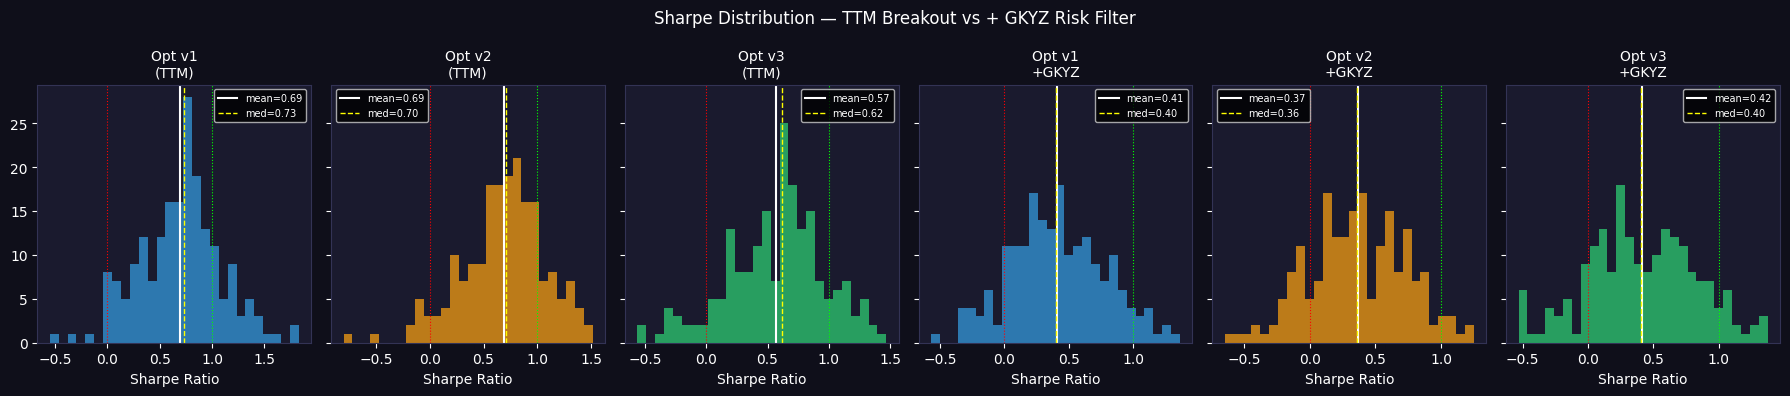

In [112]:
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

entries_list = [
    *[(f'Opt {v}\n(TTM)',  portfolios_ttm[v],  COLORS[v]) for v in ['v1', 'v2', 'v3']],
    *[(f'Opt {v}\n+GKYZ', portfolios_gkyz[v], COLORS[v]) for v in ['v1', 'v2', 'v3']],
]

n = len(entries_list)
fig, axes = plt.subplots(1, n, figsize=(max(18, 3.0 * n), 4), sharey=True)
fig.patch.set_facecolor('#0f0f1a')

for ax, (name, pf, col) in zip(axes, entries_list):
    sv = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    ax.set_facecolor('#1a1a2e')
    ax.hist(sv, bins=28, color=col, alpha=0.75, edgecolor='none')
    ax.axvline(sv.mean(),   color='white',  lw=1.5, ls='-',  label=f'mean={sv.mean():.2f}')
    ax.axvline(sv.median(), color='yellow', lw=1.0, ls='--', label=f'med={sv.median():.2f}')
    ax.axvline(0, color='red',  lw=0.8, ls=':')
    ax.axvline(1, color='lime', lw=0.8, ls=':')
    ax.set_title(name, color='white', fontsize=10)
    ax.set_xlabel('Sharpe Ratio', color='white')
    ax.tick_params(colors='white')
    ax.legend(fontsize=7)
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

plt.suptitle('Sharpe Distribution — TTM Breakout vs + GKYZ Risk Filter', color='white', fontsize=12)
plt.tight_layout()
plt.show()

## 12. Delta Sharpe vs Baseline (No Filter)

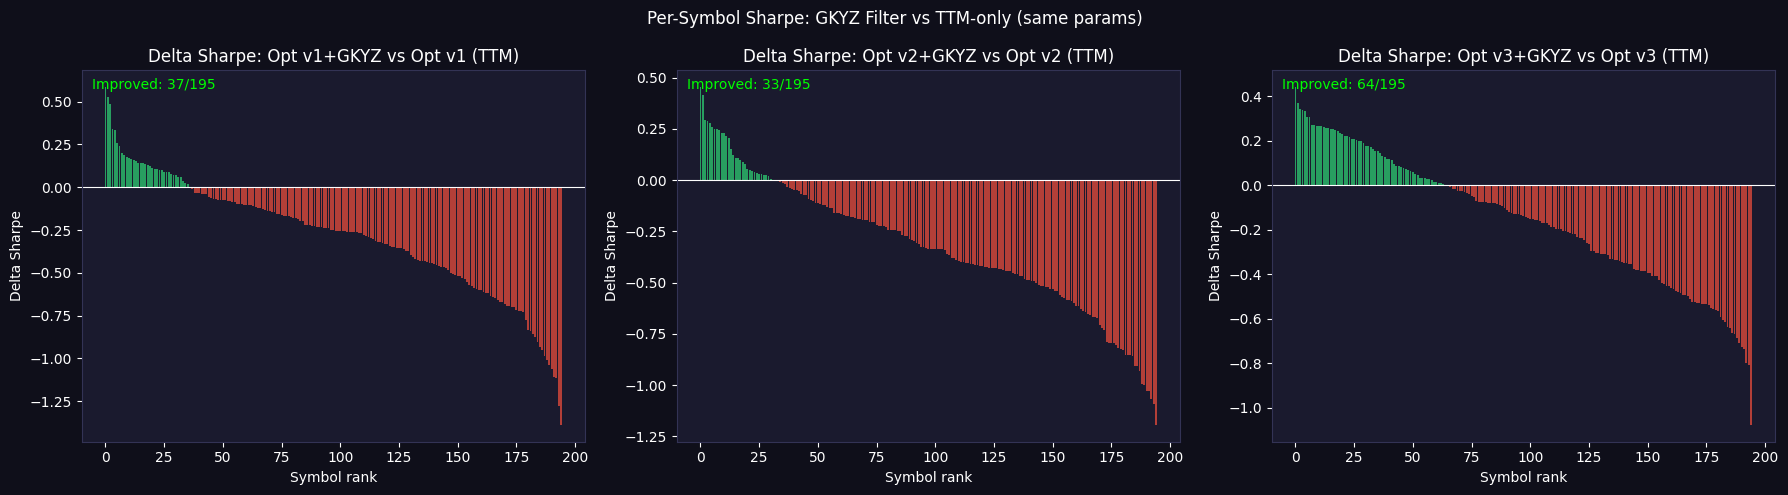

In [113]:
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f0f1a')

for ax, ver in zip(axes, ['v1', 'v2', 'v3']):
    sr_ttm  = portfolios_ttm[ver].sharpe_ratio().replace([np.inf, -np.inf], np.nan)
    sr_gkyz = portfolios_gkyz[ver].sharpe_ratio().replace([np.inf, -np.inf], np.nan)
    delta   = (sr_gkyz - sr_ttm).dropna().sort_values(ascending=False)
    colors  = ['#2ecc71' if v >= 0 else '#e74c3c' for v in delta]
    ax.set_facecolor('#1a1a2e')
    ax.bar(range(len(delta)), delta.values, color=colors, alpha=0.75)
    ax.axhline(0, color='white', lw=0.8)
    ax.set_title(f'Delta Sharpe: Opt {ver}+GKYZ vs Opt {ver} (TTM)', color='white')
    ax.set_xlabel('Symbol rank', color='white')
    ax.set_ylabel('Delta Sharpe', color='white')
    ax.tick_params(colors='white')
    improved = (delta > 0).sum()
    ax.text(0.02, 0.95, f'Improved: {improved}/{len(delta)}',
            transform=ax.transAxes, color='lime', fontsize=10)
    for sp in ax.spines.values(): sp.set_edgecolor('#333355')

plt.suptitle('Per-Symbol Sharpe: GKYZ Filter vs TTM-only (same params)', color='white', fontsize=12)
plt.tight_layout()
plt.show()

## 13. Single-Symbol — TTM Entries with GKYZ Regime Overlay

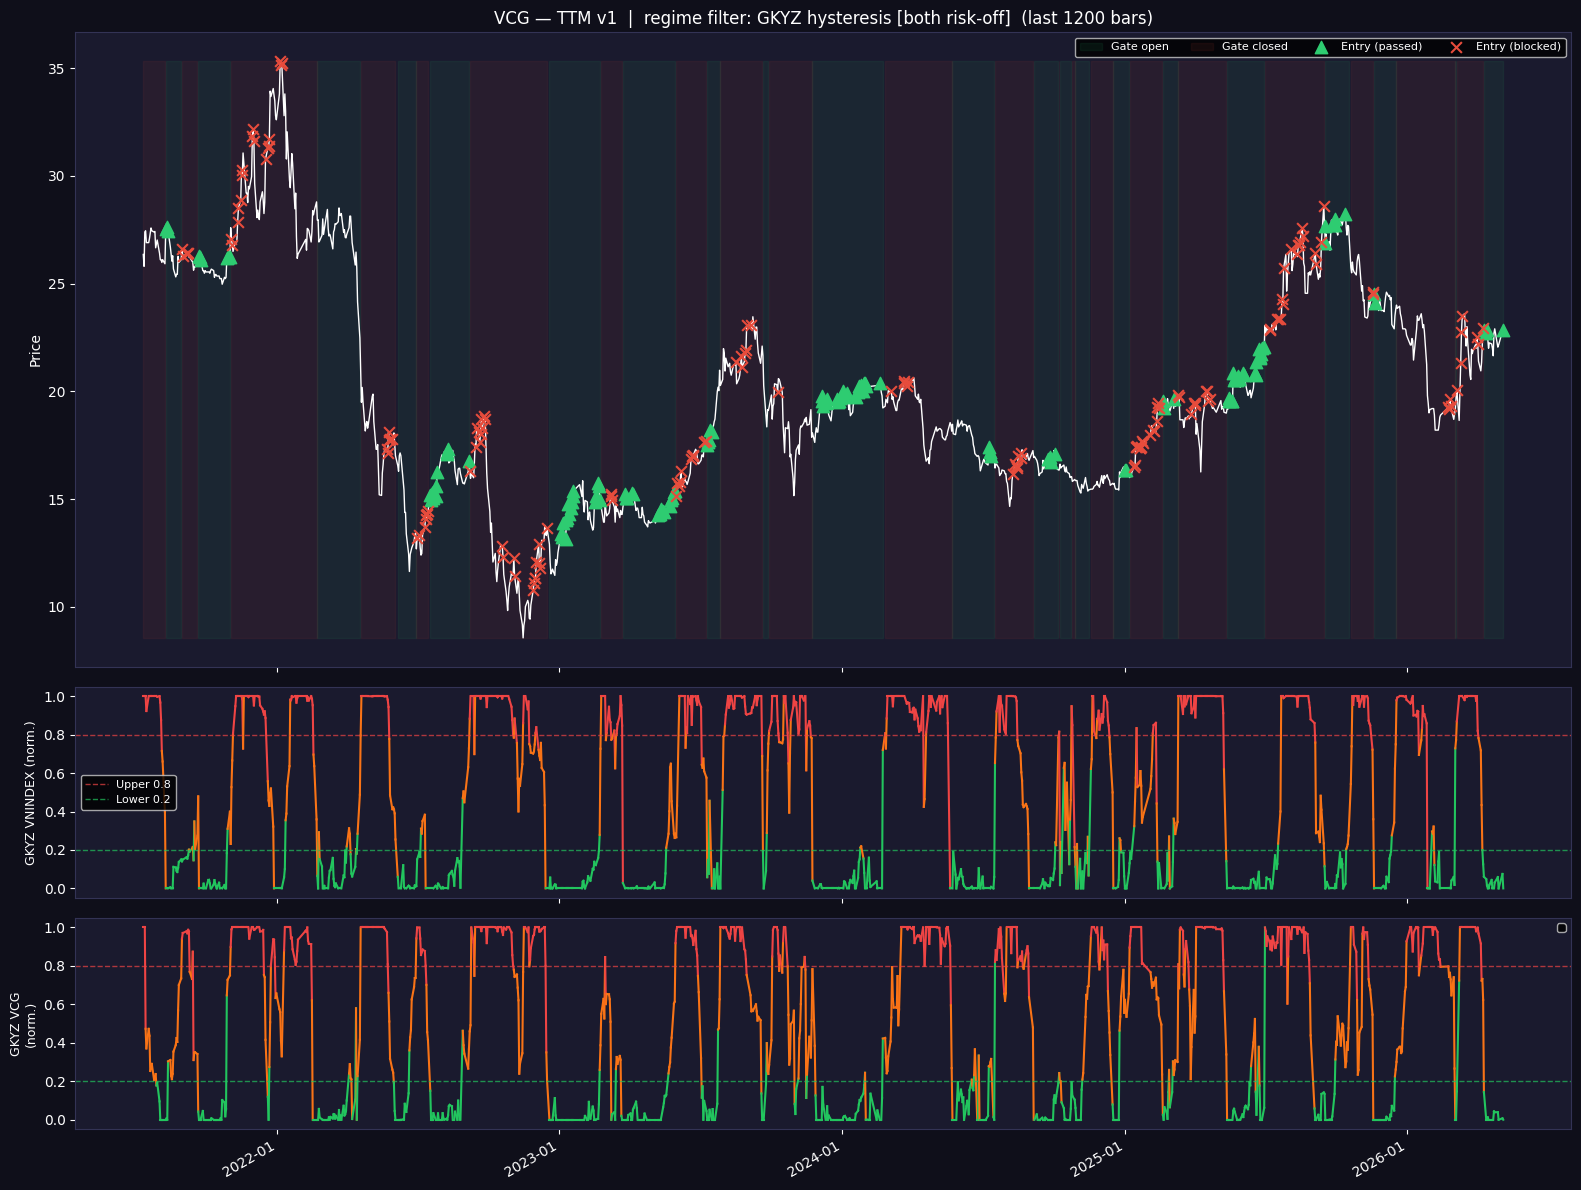

VCG | Sharpe: 0.295  Total Ret: 31.6%  [regime=v1]


In [114]:
VER            = 'v1'
SYMBOL         = 'VCG'
LOOKBACK_DAYS  = 1200
REGIME_VERSION = 'v1'

# ── regime params from FIXED_TTM_PARAMS ──────────────────────────────────────
p = FIXED_TTM_PARAMS[VER]
rv = REGIME_VERSION

regime_kwargs_vn = (
    dict(window=p.get('gkyz_window', 21), upper=p.get('gkyz_upper', 0.8), lower=p.get('gkyz_lower', 0.2))
    if rv == 'v1' else
    dict(short_window=p.get('yz_short_window', DEFAULT_YZ_SHORT_WINDOW), long_window=p.get('yz_long_window', DEFAULT_YZ_LONG_WINDOW),
         risk_off_threshold=p.get('yz_risk_off', 1.0), risk_on_threshold=p.get('yz_risk_on', 1.0))
)

# ── compute regime for VNINDEX and symbol ─────────────────────────────────────
vol_vn,  ron_vn  = compute_regime(open_['VNINDEX'], high['VNINDEX'], low['VNINDEX'], close['VNINDEX'],
                                   regime_version=rv, **regime_kwargs_vn)
vol_sym, ron_sym = compute_regime(open_[SYMBOL],    high[SYMBOL],    low[SYMBOL],    close[SYMBOL],
                                   regime_version=rv, **regime_kwargs_vn)

# ── TTM entry signals ─────────────────────────────────────────────────────────
ttm_entries_raw = compute_signals(
    close, high, low, volume,
    bb_window=p['bb_window'], bb_multiplier=p['bb_multiplier'],
    bb_matype=p.get('bb_matype', 0),
    kc_window=p['kc_window'], kc_multiplier=p['kc_multiplier'],
    kc_atr_period=p['kc_atr_period'],
    donichan_window=p['donichan_window'], osc_smoothing_period=p['osc_smoothing_period'],
    entry_version=VER,
    consecutive_neg_threshold=p.get('consecutive_neg_threshold', 7),
    william_vix_period=p.get('william_vix_period', 20),
    use_avwap_filter=True,
    avwap_window=p.get('avwap_window', 200),
    use_kama_slope=True,
    kama_period=p.get('kama_period', 10), kama_fast=p.get('kama_fast', 2),
    kama_slow=p.get('kama_slow', 30), kama_slope_win=p.get('kama_slope_win', 5),
    flat_threshold_pct=p.get('flat_threshold_pct', 1.0),
)

# ── slice to lookback window ──────────────────────────────────────────────────
dates   = close.index
n_show  = min(LOOKBACK_DAYS, len(dates))
sl_     = slice(-n_show, None)
dates_s = dates[sl_]
c_s     = close[SYMBOL].values[sl_]

ttm_raw  = ttm_entries_raw[SYMBOL].values.astype(bool)[sl_]
vn_arr   = ron_vn.values[sl_]
sym_arr  = ron_sym.values[sl_]
vol_vn_s = vol_vn.reindex(dates_s).values
vol_sy_s = vol_sym.reindex(dates_s).values

gate_arr      = (vn_arr & sym_arr) if VER == 'v3' else (~vn_arr & ~sym_arr)
entry_passed  = ttm_raw &  gate_arr
entry_blocked = ttm_raw & ~gate_arr

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1, 1]})
fig.patch.set_facecolor('#0f0f1a')

# ── [0] Price + entry markers ─────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#1a1a2e')
ax.fill_between(dates_s, c_s.min(), c_s.max(), where=gate_arr,
                color='#2ecc71', alpha=0.07, label='Gate open')
ax.fill_between(dates_s, c_s.min(), c_s.max(), where=~gate_arr,
                color='#e74c3c', alpha=0.07, label='Gate closed')
ax.plot(dates_s, c_s, color='white', lw=1.0)
ax.scatter(dates_s[entry_passed],  c_s[entry_passed],
           marker='^', color='#2ecc71', s=80, zorder=5, label='Entry (passed)')
ax.scatter(dates_s[entry_blocked], c_s[entry_blocked],
           marker='x', color='#e74c3c', s=60, zorder=5, label='Entry (blocked)')
regime_label = 'both risk-on' if VER == 'v3' else 'both risk-off'
regime_name  = f'GKYZ hysteresis' if rv == 'v1' else f'YZ vol-ratio (20/120)'
ax.set_title(f'{SYMBOL} — TTM {VER}  |  regime filter: {regime_name} [{regime_label}]  '
             f'(last {n_show} bars)', color='white', fontsize=12)
ax.set_ylabel('Price', color='white')
ax.legend(fontsize=8, ncol=4)
ax.tick_params(colors='white')
for sp in ax.spines.values(): sp.set_edgecolor('#333355')

# ── [1] VNINDEX indicator ─────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')

if rv == 'v1':
    upper = p.get('gkyz_upper', 0.8)
    lower = p.get('gkyz_lower', 0.2)
    colors_g = np.where(vol_vn_s > upper, '#ef4444',
               np.where(vol_vn_s < lower, '#22c55e', '#f97316'))
    for i in range(len(dates_s) - 1):
        ax2.plot(dates_s[i:i+2], vol_vn_s[i:i+2], color=colors_g[i], lw=1.5)
    ax2.axhline(upper, color='#ef4444', lw=1.0, ls='--', alpha=0.7, label=f'Upper {upper}')
    ax2.axhline(lower, color='#22c55e', lw=1.0, ls='--', alpha=0.7, label=f'Lower {lower}')
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_ylabel('GKYZ VNINDEX (norm.)', color='white', fontsize=9)
else:
    roff = p.get('yz_risk_off', 1.3)
    ron_ = p.get('yz_risk_on',  1.8)
    colors_g = np.where(vol_vn_s > ron_,  '#22c55e',
               np.where(vol_vn_s < roff,  '#ef4444', '#facc15'))
    for i in range(len(dates_s) - 1):
        ax2.plot(dates_s[i:i+2], vol_vn_s[i:i+2], color=colors_g[i], lw=1.5)
    ax2.axhline(ron_,  color='#22c55e', lw=1.0, ls='--', alpha=0.7, label=f'risk_on >{ron_}')
    ax2.axhline(roff,  color='#ef4444', lw=1.0, ls='--', alpha=0.7, label=f'risk_off <{roff}')
    ax2.set_ylabel('YZ vol ratio\nVNINDEX (20/120)', color='white', fontsize=9)

ax2.legend(fontsize=8)
ax2.tick_params(colors='white')
for sp in ax2.spines.values(): sp.set_edgecolor('#333355')

# ── [2] Symbol indicator ──────────────────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor('#1a1a2e')

if rv == 'v1':
    upper = p.get('gkyz_upper', 0.8)
    lower = p.get('gkyz_lower', 0.2)
    colors_s = np.where(vol_sy_s > upper, '#ef4444',
               np.where(vol_sy_s < lower, '#22c55e', '#f97316'))
    for i in range(len(dates_s) - 1):
        ax3.plot(dates_s[i:i+2], vol_sy_s[i:i+2], color=colors_s[i], lw=1.5)
    ax3.axhline(upper, color='#ef4444', lw=1.0, ls='--', alpha=0.7)
    ax3.axhline(lower, color='#22c55e', lw=1.0, ls='--', alpha=0.7)
    ax3.set_ylim(-0.05, 1.05)
    ax3.set_ylabel(f'GKYZ {SYMBOL}\n(norm.)', color='white', fontsize=9)
else:
    roff = p.get('yz_risk_off', 1.3)
    ron_ = p.get('yz_risk_on',  1.8)
    colors_s = np.where(vol_sy_s > ron_,  '#22c55e',
               np.where(vol_sy_s < roff,  '#ef4444', '#facc15'))
    for i in range(len(dates_s) - 1):
        ax3.plot(dates_s[i:i+2], vol_sy_s[i:i+2], color=colors_s[i], lw=1.5)
    ax3.axhline(ron_,  color='#22c55e', lw=1.0, ls='--', alpha=0.7)
    ax3.axhline(roff,  color='#ef4444', lw=1.0, ls='--', alpha=0.7)
    ax3.set_ylabel(f'YZ vol ratio\n{SYMBOL} (20/120)', color='white', fontsize=9)

ax3.legend(fontsize=8)
ax3.tick_params(colors='white')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=30)
for sp in ax3.spines.values(): sp.set_edgecolor('#333355')

plt.tight_layout()
plt.show()

pf_sym = portfolios_gkyz[VER]
print(f'{SYMBOL} | Sharpe: {pf_sym.sharpe_ratio()[SYMBOL]:.3f}  '
      f'Total Ret: {pf_sym.total_return()[SYMBOL]*100:.1f}%  '
      f'[regime={rv}]')
